# t-SNE & UMAP: Visualizing high-dimensional digits

This notebook uses the Optical Digits dataset from the `models.md` table to visualize 64-dimensional digit vectors in 2D using t-SNE and UMAP.

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


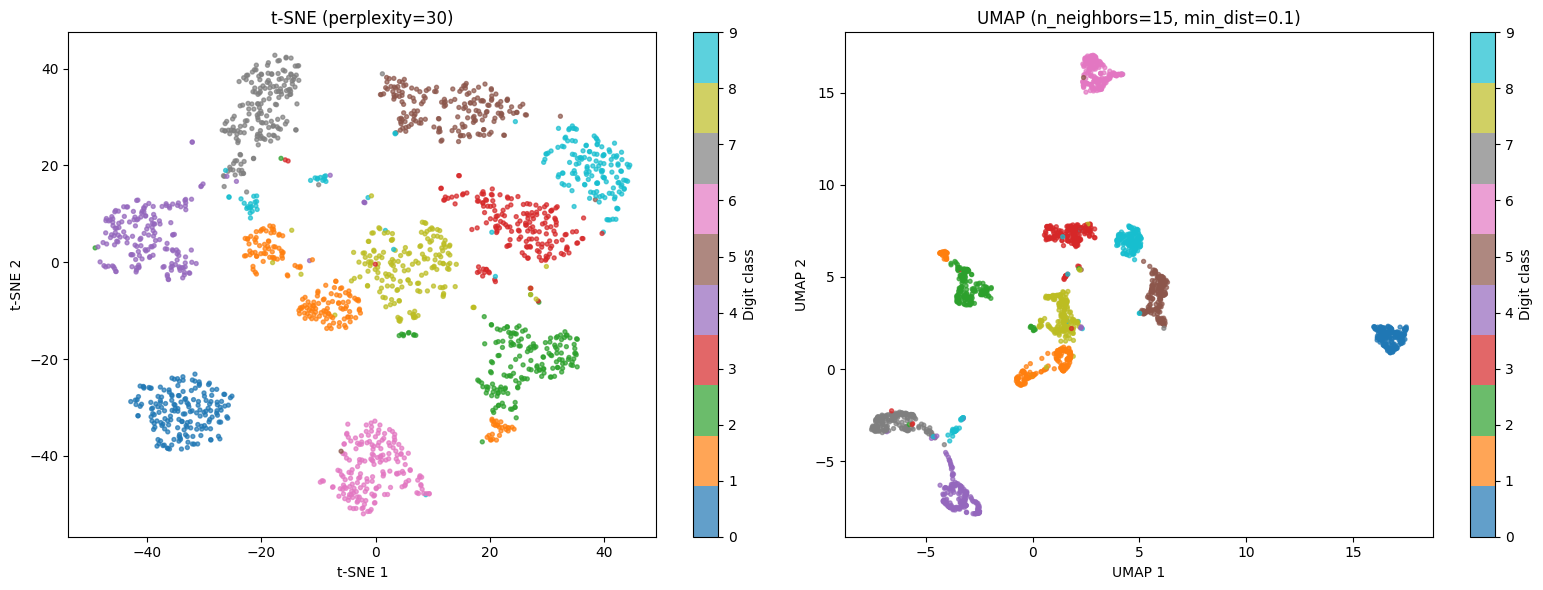

Dataset shape:  (1797, 64)
Classes:        [0 1 2 3 4 5 6 7 8 9]
t-SNE KL div:   0.8371


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Load and scale ----------
digits = load_digits()
X, y = digits.data, digits.target          # (1797, 64), 10 classes
X_scaled = StandardScaler().fit_transform(X)

# ---------- t-SNE ----------
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter0 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10',
                           s=8, alpha=0.7)
axes[0].set_title('t-SNE (perplexity=30)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
plt.colorbar(scatter0, ax=axes[0], label='Digit class')

# ---------- UMAP ----------
try:
    from umap import UMAP
    reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    scatter1 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10',
                               s=8, alpha=0.7)
    axes[1].set_title('UMAP (n_neighbors=15, min_dist=0.1)')
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    plt.colorbar(scatter1, ax=axes[1], label='Digit class')
except ImportError:
    axes[1].text(0.5, 0.5, 'umap-learn not installed\npip install umap-learn',
                ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('UMAP (not available)')

plt.tight_layout()
plt.show()

print(f'Dataset shape:  {X.shape}')
print(f'Classes:        {np.unique(y)}')
print(f't-SNE KL div:   {tsne.kl_divergence_:.4f}')

## t-SNE & UMAP: theory, loss functions, and hyperparameters

### Notation

- $\mathbf{x}_i \in \mathbb{R}^D$: original high-dimensional point (here $D=64$).
- $\mathbf{y}_i \in \mathbb{R}^2$: low-dimensional embedding.
- $p_{j|i}$: conditional probability that $\mathbf{x}_i$ would pick $\mathbf{x}_j$ as a neighbor in the high-dimensional space.
- $q_{ij}$: probability that $\mathbf{y}_i$ and $\mathbf{y}_j$ are neighbors in the low-dimensional space.

### t-SNE (t-distributed Stochastic Neighbor Embedding)

**High-dimensional affinities** use a Gaussian kernel centered on each point:

$$p_{j|i} = \frac{\exp\!\bigl(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2\bigr)}{\sum_{k \neq i} \exp\!\bigl(-\|\mathbf{x}_i - \mathbf{x}_k\|^2 / 2\sigma_i^2\bigr)}$$

These are symmetrized: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2N}$.

The bandwidth $\sigma_i$ is chosen so the effective number of neighbors matches the **perplexity**:

$$\mathrm{Perplexity} = 2^{H(P_i)}, \qquad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}$$

**Low-dimensional affinities** use a Student-$t$ distribution with one degree of freedom (heavy tails):

$$q_{ij} = \frac{\bigl(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2\bigr)^{-1}}{\sum_{k \neq l}\bigl(1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2\bigr)^{-1}}$$

**Loss function** — minimizes the KL divergence from $P$ to $Q$:

$$C = D_{\mathrm{KL}}(P\|Q) = \sum_{i \neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}}$$

**Minimize** $C$: lower KL divergence means the 2D layout better preserves high-dimensional neighborhoods. The value $0$ means a perfect match.

#### Key hyperparameters

| Parameter | Typical range | Effect |
| --- | --- | --- |
| `perplexity` | 5–50 | Balances local vs. global structure; roughly the effective number of neighbors |
| `learning_rate` | 10–1000 (`'auto'`) | Step size for gradient descent |
| `n_iter` | 250–1000 | Number of optimization iterations |

### UMAP (Uniform Manifold Approximation and Projection)

UMAP constructs a fuzzy simplicial set (weighted $k$-neighbor graph) in high dimensions and optimizes a low-dimensional layout to match it.

**High-dimensional edge weights** combine local distances with each point's nearest-neighbor distance $\rho_i$:

$$w_{ij} = \exp\!\left(-\frac{\max(0,\, d(\mathbf{x}_i, \mathbf{x}_j) - \rho_i)}{\sigma_i}\right)$$

These are symmetrized: $\tilde{w}_{ij} = w_{ij} + w_{ji} - w_{ij}\,w_{ji}$.

**Low-dimensional edge weights** use a smooth approximation of the membership function:

$$v_{ij} = \bigl(1 + a\,\|\mathbf{y}_i - \mathbf{y}_j\|^{2b}\bigr)^{-1}$$

where $a$ and $b$ are fitted from `min_dist`.

**Loss function** — a fuzzy set cross-entropy:

$$C = \sum_{(i,j)}\Bigl[\tilde{w}_{ij}\log\frac{\tilde{w}_{ij}}{v_{ij}} + (1-\tilde{w}_{ij})\log\frac{1-\tilde{w}_{ij}}{1-v_{ij}}\Bigr]$$

**Minimize** $C$: lower cross-entropy means the 2D graph better matches the high-dimensional neighborhood graph.

#### Key hyperparameters

| Parameter | Typical range | Effect |
| --- | --- | --- |
| `n_neighbors` | 5–50 | Controls local vs. global balance; similar role to perplexity in t-SNE |
| `min_dist` | 0.0–0.99 | How tightly points can pack; lower values give tighter clusters |
| `metric` | euclidean, cosine, etc. | Distance metric for the $k$-NN graph |

### t-SNE vs. UMAP: comparison

| Aspect | t-SNE | UMAP |
| --- | --- | --- |
| Speed | $O(N \log N)$ with Barnes-Hut | Generally faster, especially on large $N$ |
| Global structure | Tends to lose it (KL is asymmetric) | Better preserved (cross-entropy is symmetric) |
| Reproducibility | Stochastic; varies across runs | Stochastic; set `random_state` for reproducibility |
| New-point embedding | Not supported natively | Supports `transform()` on unseen data |
| Theory | Probability divergence minimization | Algebraic topology (fuzzy simplicial sets) |